# Training U-Net model from scratch


This project trains a U-Net model from scratch. The dataset used here is the Oxford Pet dataset. 

In [1]:
import os, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A #for image transformations to training data
from albumentations.pytorch import ToTensorV2

from PIL import Image #Pillow lib for image manipulation
from torchvision.datasets import OxfordIIITPet

In [2]:
#DOWNLOAD DATASET

root= Path("/content/data")
root.mkdir(parents=True, exist_ok=True)

#download Oxford dataset for segmentation. It returns trimap masks with values in {1,2,3}
#A trimap is a segmentation mask with three regions instead of just foreground/background.
#3 regions of tripmap are pet, bg and border (Marks pixels near object boundary)

data_TV=OxfordIIITPet(root=root, split="trainval", target_types= "segmentation", download=True)
data_test= OxfordIIITPet(root=root, split="test", target_types="segmentation", download=True)

#returns each sample returns:(image, mask)



100%|██████████| 792M/792M [00:35<00:00, 22.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.8MB/s]


In [3]:
img, mask = data_TV[0]

print(type(mask))
print(mask.size)
print(img.size)

import numpy as np
np.unique(np.array(mask))

<class 'PIL.PngImagePlugin.PngImageFile'>
(394, 500)
(394, 500)


array([1, 2, 3], dtype=uint8)

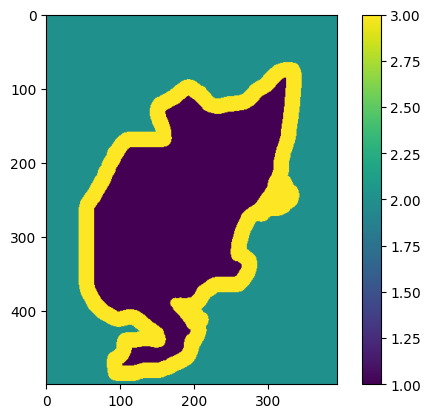

In [4]:
plt.imshow(mask) #It will show image with 3 intensity levels
plt.colorbar()

In [5]:
from albumentations.augmentations.pixel.transforms import ColorJitter
#custom dataset wrapper
#apply transformation to images and convert trimap to binary mask (forground: 2,3 and bg as 1)

img_size = 384 #target size

train_transforms = A.Compose([
    A.LongestMaxSize(max_size=img_size),
    A.PadIfNeeded(img_size, img_size, border_mode=cv2.BORDER_CONSTANT, value=0),#If the image is smaller than imgximg, then pad
    A.RandomRotate90(p=0.2),
    A.HorizontalFlip(p=0.2),
    A.VerticalFlip(p=0.5),
    A.ColorJitter(p=0.2, brightness=0.2, saturation=0.05),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

eval_transforms = A.Compose([
      A.LongestMaxSize(max_size= img_size)  ,
      A.PadIfNeeded(img_size, img_size, border_mode=cv2.BORDER_CONSTANT, value=0),
      A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
      ToTensorV2(),
])

/tmp/ipykernel_239/2885279209.py:9: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(img_size, img_size, border_mode=cv2.BORDER_CONSTANT, value=0),#If the image is smaller than imgximg, then pad
/tmp/ipykernel_239/2885279209.py:20: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(img_size, img_size, border_mode=cv2.BORDER_CONSTANT, value=0),


LongestMaxSize(max_size=384) resizes each image so its longest side becomes 384 while preserving aspect ratio, preventing distortion of pet shapes (important for segmentation boundaries).

Then PadIfNeeded(min_height=384, border_mode=cv2.BORDER_CONSTANT, value=0) pads the remaining dimension to make the image exactly 384×384; constant padding with value 0 adds black pixels, ensuring uniform batch shapes required for CNN training without warping geometry.

The geometric augmentations (RandomRotate90(p=0.2), HorizontalFlip(p=0.2), VerticalFlip(p=0.5)) increase invariance to orientation and reflection — pets may appear in different poses, and U-Net benefits from seeing flipped spatial patterns so it doesn’t overfit to one canonical orientation. The probabilities (0.2–0.5) are moderate to avoid excessive distortion while still injecting variability.

ColorJitter(p=0.2, brightness=0.2, saturation=0.05) improves robustness to illumination changes; brightness variation (±20%) simulates lighting differences, while small saturation change (5%) prevents drastic color shifts that could distort fur texture cues. Color jitter Simulates:
Different lighting conditions; Indoor vs outdoor; Shadows

Normalize numbers are taken from Image-Net stats. They are good to ensure stable neural net training.




In [13]:
#custom dataset class

class ImgData(Dataset):
  def __init__(self, data, trf):
    self.data= data #base dataset
    self.trf= trf #transformations

  def __len__(self):
    return len(self.data) #return no.of samples in data

  def __getitem__(self, idx):
    img1, mask1 =self.data[idx]
    img= np.array(img1.convert("RGB"))
    mask =np.array(mask1)

    #create binary mask: {2,3} as foreground and {1} as bg
   ## mask_bin= ((mask>1).astype(np.uint8))*255

    mask_bin = (mask > 1).astype(np.float32)

    #apply transforms to image and mask
    out = self.trf(image=img, mask=mask_bin)
    img = out["image"]
    mask = out["mask"].float()

    return img, mask


#split the dataset into train and val sets
torch.manual_seed(42) #Use generator if:You want deterministic batch ordering
train_len= int(0.9 * len(data_TV))
val_len= len(data_TV) - train_len
train_ds, val_ds= random_split(data_TV, [train_len, val_len])

#create instances of our custom dataset for train. val and test
train_final= ImgData(train_ds, train_transforms) # Corrected to use train_transforms
val_final= ImgData(val_ds, eval_transforms) # Corrected to use eval_transforms
test_final= ImgData(data_test, eval_transforms) # Corrected to use eval_transforms

#create dataloaders
train_loader = DataLoader(train_final, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader  = DataLoader(val_final, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

#workers help parallel data loading CPU workers prepare batch N+1; GPU trains on batch N
#pin_memory is for efficient transfer from CPU → GPU; Asynchronous GPU transfer;Better training throughput

In [14]:
#U-NET model

#1st define double conv block

class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.net =nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True), #inplace is for saving memory..instead of y=Relu(x) and storing both x and y, we just put Relu(x)
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.net(x)

class DownSample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.net= nn.Sequential(
        nn.MaxPool2d(2),
        DoubleConv(in_channels, out_channels) #after maxpooling, the new layer has 2 conv ops.
    )

  def forward(self, x):
    return self.net(x)


class UpSample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels) #cant use sequential becuz we add skip connect; sequential can do : output = module(input), but not output = module(input1, input2)

  def forward(self, x1, x2):
    #x1 is from prev. upsample layer, x2 is skip from encoder
    x1= self.up(x1)
    diff_y = x2.size(2) - x1.size(2)
    diff_x = x2.size(3) - x1.size(3)

    x1 = F.pad(x1,[diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2,],)
    x = torch.cat([x2, x1], dim=1)
    return self.conv(x)


class UNET(nn.Module):
  def __init__(self, in_channels=3, base=32):
    super().__init__()
    #encoder
    self.inc = DoubleConv(in_channels, base)
    self.down1 = DownSample(base, base*2)
    self.down2 = DownSample(base*2, base*4)
    self.down3 = DownSample(base*4, base*8)
    self.down4 = DownSample(base*8,base*16)

    #decoder
    self.up1 = UpSample(base*16, base*8)
    self.up2 = UpSample(base*8, base*4)
    self.up3 = UpSample(base*4, base*2)
    self.up4 = UpSample(base*2,base)

    #output
    self.out = nn.Conv2d(base, 1, kernel_size=1)

  def forward(self, x):
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)

    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.up3(x, x2)
    x = self.up4(x, x1)
    return self.out(x)

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
model= UNET().to(device)




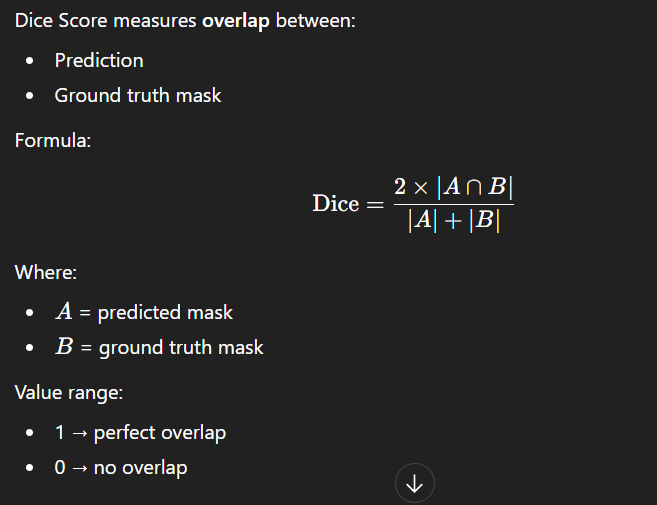

In [20]:
#loss
class UNetLoss(nn.Module):
  def __init__(self,eps=1e-60):
    super().__init__()
    self.eps= eps #to stop zero division issue

  def forward(self, logits, targets):
    probs= torch.sigmoid(logits) #sigmoid on output for binary class to get probabilities
    num = 2 * (probs * targets).sum(dim=(2,3)) +self.eps #(2,3) becuz the input dim is (batch, channels, H,W)...we care abt H and W only
    den = probs.pow(2).sum(dim=(2,3)) + targets.pow(2).sum(dim=(2,3)) + self.eps
    return 1 - (num / den).mean() #mean is for across batch

bce= nn.BCEWithLogitsLoss() #1st loss is binary cross entropy loss. This if for non-matching pixel values w.r.t ground truth
dice_loss =UNetLoss()

#combine loss function
def loss_tot(output, target, alpha=0.5):
  return alpha * bce(output, target) + (1-alpha) * dice_loss (output, target)

#2nd loss is for IOU based loss

def IOUscore(output, targets, thr=0.5):

  output= torch.sigmoid(output)
  pred =(output > thr).float()
  inter = (pred * targets).sum(dim=(1,2,3))
  union = (pred + targets - pred * targets).sum(dim=(1,2,3)) + 1e-6 #tensor shape [BATCH, CHANNEL, HEIGHT, WIDTH]

  return (inter / union).mean()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer) #no. of epochs for cosine cycle is T_max, and is only used in cosine-kinda schedulers
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.3,
    patience=3
)

In [16]:

#  Training loop


EPOCHS = 5  # Number of training epochs (adjust upward for potentially better results)
best_val_iou = 0.0  # Initialize the best validation IoU score
ckpt_path = "/content/unet_oxfordpet.pth"  # Path to save the best model checkpoint

train_losses = []
val_losses = []
val_ious = []

# Loop over the specified number of epochs
for epoch in range(1, EPOCHS + 1):
    model.train()  # Set the model to training mode
    train_loss = 0.0  # Initialize training loss for the epoch

    # Create a progress bar for the training data loader
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")

    # Iterate over batches in the training data loader
    for imgs, masks in pbar:
        # Move images and masks to the device (GPU or CPU)
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Ensure masks have a channel dimension and are float for loss calculation
        if masks.ndim == 3:  # If masks are (B, H, W), add channel dimension
            masks = masks.unsqueeze(1)
        masks = masks.float()  # Ensure float type

        optimizer.zero_grad()  # Zero the gradients of model parameters
        logits = model(imgs)  # Perform a forward pass to get model outputs (logits)
        loss_value = loss_tot(logits, masks)  # Calculate the loss

        loss_value.backward()  # Perform backpropagation to calculate gradients
        optimizer.step()  # Update model parameters using the optimizer

        train_loss += loss_value.item() * imgs.size(0)  # Accumulate training loss
        pbar.set_postfix(loss=float(loss_value))  # Update the progress bar with the current loss

    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0  # Initialize validation loss for the epoch
    val_iou= 0.0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            # Ensure masks have a channel dimension and are float for loss calculation
            if masks.ndim == 3:  # If masks are (B, H, W), add channel dimension
                masks = masks.unsqueeze(1)
            masks = masks.float()  # Ensure float type

            logits = model(imgs)
            loss_value  = loss_tot(logits, masks)

            val_loss += loss_value .item() * imgs.size(0)
            val_iou += IOUscore(logits, masks) * imgs.size(0)


    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    #print epoch summary
    print(f"Epoch {epoch}/{EPOCHS}: train_loss= {train_loss:.4f};   val_loss= {val_loss:.4f};  val_iou= {val_iou:.4f}")

    #save model checpoint if current val IOU is best
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), ckpt_path)
        print(f"Saved best model with IoU={best_val_iou:.4f}")

Epoch 1/5 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

/tmp/ipykernel_239/3255838354.py:39: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  pbar.set_postfix(loss=float(loss_value))  # Update the progress bar with the current loss


Epoch 1/5: train_loss= 0.2953;   val_loss= 0.2296;  val_iou= 0.7704
Saved best model with IoU=0.7704


Epoch 2/5 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2/5: train_loss= 0.2185;   val_loss= 0.2018;  val_iou= 0.7707
Saved best model with IoU=0.7707


...

Epoch 3/5: train_loss= 0.1906;   val_loss= 0.1988;  val_iou= 0.7816
Saved best model with IoU=0.7816


Epoch 4/5 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 4/5: train_loss= 0.1702;   val_loss= 0.1445;  val_iou= 0.8373
Saved best model with IoU=0.8373


Epoch 5/5 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 5/5: train_loss= 0.1649;   val_loss= 0.1312;  val_iou= 0.8496
Saved best model with IoU=0.8496


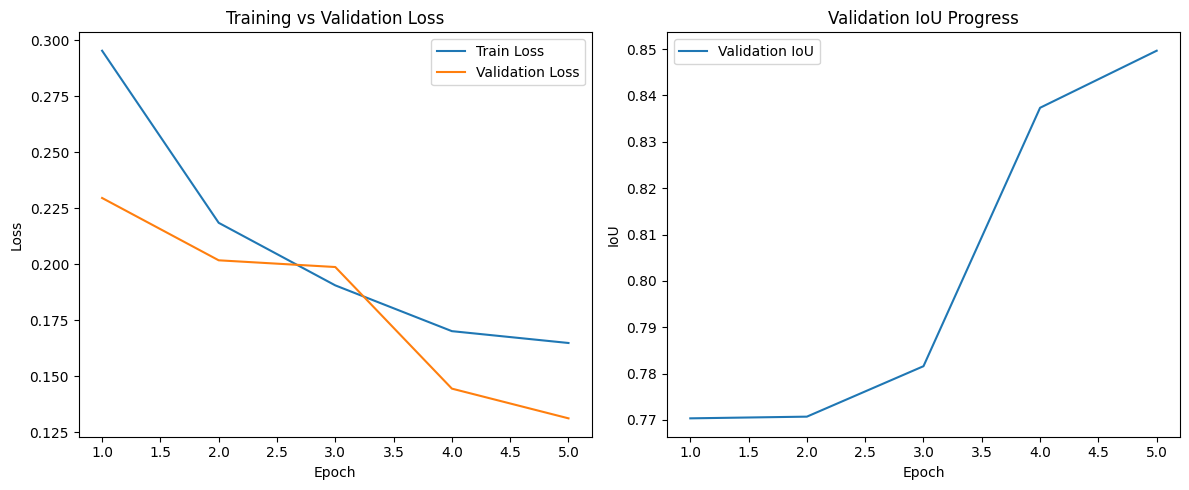

In [18]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))


# Loss curve
plt.subplot(1,2,1)

plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()


# IoU curve
plt.subplot(1,2,2)

# Convert val_IOUs from list of CUDA tensors to list of CPU numpy arrays
val_ious_cpu = [iou.cpu().numpy() for iou in val_ious]
plt.plot(epochs_range, val_ious_cpu, label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU Progress")
plt.legend()


plt.tight_layout()
plt.show()

# more epochs

In [21]:

#  Training loop


EPOCHS = 30  # Number of training epochs (adjust upward for potentially better results)
best_val_iou = 0.0  # Initialize the best validation IoU score
ckpt_path = "/content/unet_oxfordpet.pth"  # Path to save the best model checkpoint

train_losses = []
val_losses = []
val_ious = []

# Loop over the specified number of epochs
for epoch in range(1, EPOCHS + 1):
    model.train()  # Set the model to training mode
    train_loss = 0.0  # Initialize training loss for the epoch

    # Create a progress bar for the training data loader
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")

    # Iterate over batches in the training data loader
    for imgs, masks in pbar:
        # Move images and masks to the device (GPU or CPU)
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Ensure masks have a channel dimension and are float for loss calculation
        if masks.ndim == 3:  # If masks are (B, H, W), add channel dimension
            masks = masks.unsqueeze(1)
        masks = masks.float()  # Ensure float type

        optimizer.zero_grad()  # Zero the gradients of model parameters
        logits = model(imgs)  # Perform a forward pass to get model outputs (logits)
        loss_value = loss_tot(logits, masks)  # Calculate the loss

        loss_value.backward()  # Perform backpropagation to calculate gradients
        optimizer.step()  # Update model parameters using the optimizer

        train_loss += loss_value.item() * imgs.size(0)  # Accumulate training loss
        pbar.set_postfix(loss=float(loss_value))  # Update the progress bar with the current loss

    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0  # Initialize validation loss for the epoch
    val_iou= 0.0

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            # Ensure masks have a channel dimension and are float for loss calculation
            if masks.ndim == 3:  # If masks are (B, H, W), add channel dimension
                masks = masks.unsqueeze(1)
            masks = masks.float()  # Ensure float type

            logits = model(imgs)
            loss_value  = loss_tot(logits, masks)

            val_loss += loss_value .item() * imgs.size(0)
            val_iou += IOUscore(logits, masks) * imgs.size(0)


    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    #print epoch summary
    print(f"Epoch {epoch}/{EPOCHS}: train_loss= {train_loss:.4f};   val_loss= {val_loss:.4f};  val_iou= {val_iou:.4f}")

    #save model checpoint if current val IOU is best
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), ckpt_path)
        print(f"Saved best model with IoU={best_val_iou:.4f}")

Epoch 1/30 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 1/30: train_loss= 0.1518;   val_loss= 0.1600;  val_iou= 0.8350
Saved best model with IoU=0.8350


Epoch 2/30 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2/30: train_loss= 0.1425;   val_loss= 0.2292;  val_iou= 0.7458


Epoch 3/30 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss= 0.0771;   val_loss= 0.0796;  val_iou= 0.9057


Epoch 29/30 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 29/30: train_loss= 0.0781;   val_loss= 0.0783;  val_iou= 0.9060


Epoch 30/30 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 30/30: train_loss= 0.0763;   val_loss= 0.0794;  val_iou= 0.9049


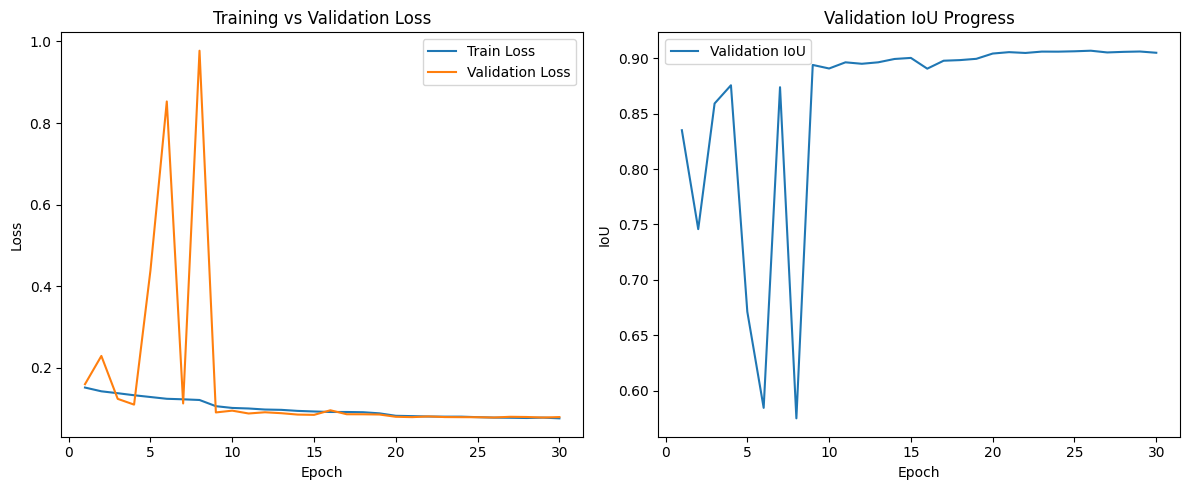

In [22]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))


# Loss curve
plt.subplot(1,2,1)

plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()


# IoU curve
plt.subplot(1,2,2)

# Convert val_IOUs from list of CUDA tensors to list of CPU numpy arrays
val_ious_cpu = [iou.cpu().numpy() for iou in val_ious]
plt.plot(epochs_range, val_ious_cpu, label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU Progress")
plt.legend()


plt.tight_layout()
plt.show()

# Observations from the experiment

The U-Net model demonstrated strong and stable learning behavior during training. The training loss steadily decreased across epochs, indicating effective optimization and convergence of the model parameters. Although the validation loss showed some fluctuations during the early epochs (may be due to initial instability and batch variability) it quickly stabilized and followed a similar downward trend as the training loss. The close alignment between training and validation loss suggests that the model generalizes well to unseen data and does not exhibit signs of significant overfitting.

Segmentation performance, measured using the Intersection over Union (IoU) metric, improved consistently throughout training. After some variability in the initial epochs, the validation IoU increased rapidly and eventually plateaued around 0.90–0.91, indicating strong segmentation accuracy.

The stabilization of both loss and IoU after approximately 15–20 epochs suggests that the model reached convergence and learned meaningful representations of the object boundaries. Overall, the results demonstrate that the implemented U-Net architecture successfully captures the relevant features of the dataset and achieves high-quality segmentation performance.